In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%%capture
!pip install -q --force-reinstall "numpy==1.26.4" "albumentations==1.4.18" opencv-python-headless

In [ ]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [ ]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [ ]:
import os, glob, json

TEST_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"
TEST_REF = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"
STAGING  = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

with open(TEST_REF) as f:
    test_labels = [int(l.strip()) for l in f if l.strip()]
test_images = sorted(p for p in glob.glob(os.path.join(TEST_DIR, "*.*"))
                     if os.path.splitext(p)[1].lower() in (".png",".jpg",".jpeg",".webp",".bmp",".tif",".tiff"))
assert len(test_images) == len(test_labels)
test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]
with open(f"{STAGING}/test.json", "w") as f:
    json.dump(test_items, f)
print(f"✓ test.json: {len(test_items)} items")

✓ test.json: 1000 items


In [ ]:
SPSL_CKPT_DIR = f"{BASE}/ForensicHub/log/crossdataset_image_new/crossdataset_spsl_train"
DRIVE_OUT_CAP    = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/spsl"
os.makedirs(DRIVE_OUT_CAP, exist_ok=True)

# pick best epoch
log_path = os.path.join(SPSL_CKPT_DIR, "log.txt")
entries = []
with open(log_path) as f:
    for line in f:
        try: entries.append(json.loads(line))
        except: pass
sample_keys = list(entries[-1].keys())
auc_key = next((k for k in sample_keys if "auc" in k.lower() and "image" in k.lower()), None)
best = max(entries, key=lambda e: e.get(auc_key, 0))
best_epoch = best["epoch"]
print(f"SPSL best epoch: {best_epoch}  ({auc_key} = {best[auc_key]:.4f})")

ckpt_path = os.path.join(SPSL_CKPT_DIR, f"checkpoint-{best_epoch}.pth")

model_args = {
    "name": "Spsl",
    "init_config": {
        "yaml_config_path": f"{BASE}/DeepfakeBench/DeepfakeBench/training/config/config/detector/spsl.yaml"
    }
}
model = build_from_registry(MODELS, model_args)
ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
state = ckpt["model"] if "model" in ckpt else ckpt
model.load_state_dict(state, strict=False)
model.to(DEVICE).eval()

post = albu.Compose([
    albu.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet
    ToTensorV2(),
])

with open(TEST_JSON) as f:
    items = json.load(f)

preds_cap, labels_cap = [], []
with torch.no_grad():
    for i, it in enumerate(items):
        img = np.array(Image.open(it["path"]).convert("RGB"))
        if img.shape[:2] != (256, 256):
            img = albu.Resize(256, 256)(image=img)["image"]
        img_t = post(image=img)["image"].unsqueeze(0).to(DEVICE)
        label = torch.tensor([it["label"]], dtype=torch.float32, device=DEVICE)
        out   = model(image=img_t, label=label)
        prob  = out["pred_label"].view(-1)[0].item()
        preds_cap.append(prob); labels_cap.append(int(it["label"]))
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(items)}")

preds_cap  = np.array(preds_cap)
labels_cap = np.array(labels_cap)
np.save(f"{DRIVE_OUT_CAP}/preds.npy",  preds_cap)
np.save(f"{DRIVE_OUT_CAP}/labels.npy", labels_cap)

y = (preds_cap >= 0.5).astype(int)
print(f"\n=== SPSL on Public Test ===")
print(f"AUC: {roc_auc_score(labels_cap, preds_cap):.4f}")
print(f"F1 : {f1_score(labels_cap, y):.4f}")
print(f"Acc: {accuracy_score(labels_cap, y):.4f}")
print(f"Saved to: {DRIVE_OUT_CAP}")

SPSL best epoch: 6  (test_image-level AUC = 0.6644)
[build_from_registry] Creating model 'Spsl' with args: {'yaml_config_path': '/content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench/DeepfakeBench/training/config/config/detector/spsl.yaml'}
  100/1000
  200/1000
  300/1000
  400/1000
  500/1000
  600/1000
  700/1000
  800/1000
  900/1000
  1000/1000

=== SPSL on Public Test ===
AUC: 0.6431
F1 : 0.5448
Acc: 0.6090
Saved to: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/spsl


In [ ]:
ROOT = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs"

p_eff = np.load(f"{ROOT}/effort/preds.npy")
l_eff = np.load(f"{ROOT}/effort/labels.npy")
p_cap = np.load(f"{ROOT}/spsl/preds.npy")
l_cap = np.load(f"{ROOT}/spsl/labels.npy")

assert p_eff.shape == p_cap.shape, "preds length mismatch"
assert np.array_equal(l_eff, l_cap), "labels mismatch — order differs"
labels = l_eff

# Soft voting
ens_prob = (p_eff + p_cap) / 2.0
ens_pred = (ens_prob >= 0.5).astype(int)

def row(name, prob):
    pred = (prob >= 0.5).astype(int)
    return name, roc_auc_score(labels, prob), f1_score(labels, pred), accuracy_score(labels, pred)

print(f"{'Model':<22}  {'AUC':>6}  {'F1':>6}  {'Acc':>6}")
print("-"*48)
for n, a, f, ac in [row("Effort", p_eff), row("SPSL", p_cap), row("Ensemble (avg)", ens_prob)]:
    print(f"{n:<22}  {a:.4f}  {f:.4f}  {ac:.4f}")

# Save ensemble
ENS = f"{ROOT}/ensemble_effort_spsl"
os.makedirs(ENS, exist_ok=True)
np.save(f"{ENS}/preds.npy",  ens_prob)
np.save(f"{ENS}/labels.npy", labels)
print(f"\nSaved ensemble to: {ENS}")

Model                      AUC      F1     Acc
------------------------------------------------
Effort                  0.7647  0.6774  0.7200
SPSL                    0.6431  0.5448  0.6090
Ensemble (avg)          0.7384  0.6253  0.6740

Saved ensemble to: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl


Checking saved Effort + SPSL ensemble outputs:
OK    /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl/preds.npy
OK    /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl/labels.npy

Copied Effort + SPSL ensemble files into one-command format:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl/ensemble_effort_spsl_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/ensemble_effort_spsl/metadata.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/ensemble_effort_spsl_test_confusion_matrix_reproduced.jpg

Metrics from copied saved Effort + SPSL ensemble:
P:    0.7351
R:    0.5440
F1:   0.

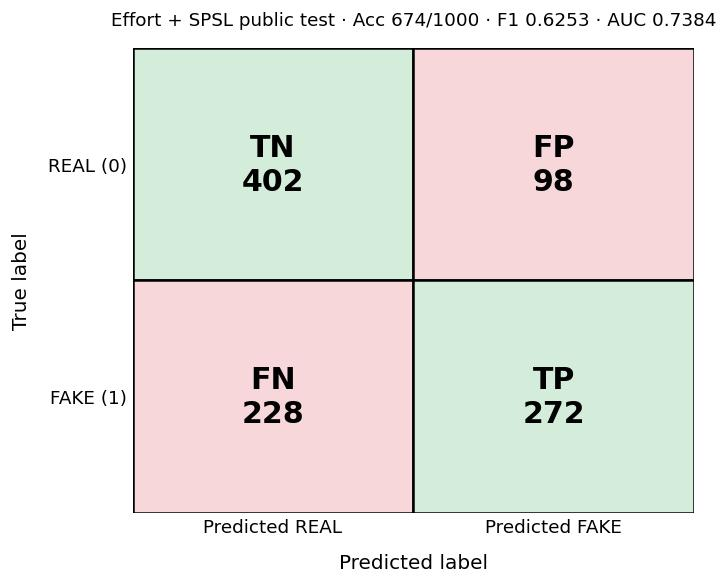

In [2]:
# ============================================================
# Copy already-saved Effort + SPSL ensemble outputs
# into one-command submission format
# DOES NOT recompute ensemble if saved files already exist
# Also saves confusion matrix figure
# ============================================================

%matplotlib inline

import json
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
)

SRC_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs")
SRC_ENS = SRC_ROOT / "ensemble_effort_spsl"

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")
DST_ENS = SUBMISSION_ROOT / "test_outputs" / "ensemble_effort_spsl"
DST_ENS.mkdir(parents=True, exist_ok=True)

FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

src_preds = SRC_ENS / "preds.npy"
src_labels = SRC_ENS / "labels.npy"

print("Checking saved Effort + SPSL ensemble outputs:")
for p in [src_preds, src_labels]:
    print(("OK   " if p.exists() else "MISS "), p)

if not src_preds.exists():
    raise FileNotFoundError(
        f"Missing {src_preds}. Run your ensemble-saving cell once first, "
        "then rerun this export cell."
    )

if not src_labels.exists():
    raise FileNotFoundError(
        f"Missing {src_labels}. Run your ensemble-saving cell once first, "
        "then rerun this export cell."
    )

# Copy only existing saved arrays; no recomputation
shutil.copy2(src_preds, DST_ENS / "preds.npy")
shutil.copy2(src_labels, DST_ENS / "labels.npy")

# Load copied files only to make metadata/results in the expected format
scores = np.load(DST_ENS / "preds.npy").astype(float).reshape(-1)
labels = np.load(DST_ENS / "labels.npy").astype(int).reshape(-1)

if len(scores) != len(labels):
    raise ValueError(f"Length mismatch: preds={len(scores)}, labels={len(labels)}")

THRESHOLD = 0.5
preds = (scores >= THRESHOLD).astype(int)

precision = precision_score(labels, preds, zero_division=0)
recall = recall_score(labels, preds, zero_division=0)
f1 = f1_score(labels, preds, zero_division=0)
acc = accuracy_score(labels, preds)
auc = roc_auc_score(labels, scores)

cm = confusion_matrix(labels, preds, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

results = []
for i, (label, score, pred) in enumerate(zip(labels, scores, preds)):
    results.append({
        "index": int(i),
        "true_label": int(label),
        "pred": int(pred),
        "score": float(score),
        "correct": bool(pred == int(label)),
    })

with open(DST_ENS / "ensemble_effort_spsl_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

metadata = {
    "model": "Effort + SPSL",
    "method": "soft_voting_average",
    "threshold": THRESHOLD,
    "source_dir": str(SRC_ENS),
    "reproduction_mode": "copied_cached_ensemble_outputs_no_recompute",
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(acc),
        "auc": float(auc),
    },
    "confusion_matrix": {
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
    },
    "num_items": int(len(labels)),
}

with open(DST_ENS / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ============================================================
# Plot same-style confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Effort + SPSL public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = FIG_DIR / "ensemble_effort_spsl_test_confusion_matrix_reproduced.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("\nCopied Effort + SPSL ensemble files into one-command format:")
print(" -", DST_ENS / "preds.npy")
print(" -", DST_ENS / "labels.npy")
print(" -", DST_ENS / "ensemble_effort_spsl_test_inference_results.json")
print(" -", DST_ENS / "metadata.json")
print(" -", fig_path)

print("\nMetrics from copied saved Effort + SPSL ensemble:")
print(f"P:    {precision:.4f}")
print(f"R:    {recall:.4f}")
print(f"F1:   {f1:.4f}")
print(f"Acc:  {acc:.4f}")
print(f"AUC:  {auc:.4f}")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Correct={correct}/{total}, Wrong={wrong}/{total}")

display(Image(filename=str(fig_path)))

Score appears to be fake probability. Using score directly.
AUC — Effort:        0.7647
AUC — SPSL:       0.6431
AUC — Ensemble:      0.7384
Score mode used:     score

Test Accuracy: 0.6740
Test F1:       0.6253
Test AUC:      0.7384
Result:        674/1000
AUC direct:    0.7384
AUC inverted:  0.2616
════════════════════════════════════════════
  Confusion Matrix Results
════════════════════════════════════════════
  TP (fake correctly detected) : 272
  TN (real correctly detected) : 402
  FP (real wrongly called fake): 98
  FN (fake wrongly called real): 228
────────────────────────────────────────────
  Precision(fake): 0.7351
  Recall(fake):    0.5440
  Wrong:           326/1000


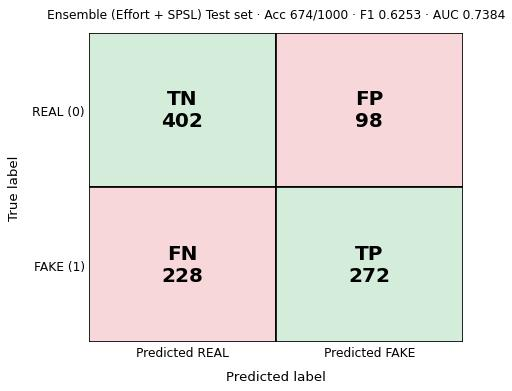


Saved plot to: /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs/ensemble_effort_spsl/confusion_matrix.jpg


In [ ]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, accuracy_score
from IPython.display import Image, display

THRESHOLD = 0.5
ROOT = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub/log/test_outputs"
ENS_DIR = f"{ROOT}/ensemble_effort_spsl"

# ── Load ensemble preds/labels ─────────────────────────────────────────────
preds  = np.load(f"{ENS_DIR}/preds.npy")
labels = np.load(f"{ENS_DIR}/labels.npy")

if len(preds) == 0:
    raise RuntimeError("Ensemble preds file is empty.")

y_true  = labels.astype(int)
y_score = preds.astype(float)

# ── Auto-detect orientation (in case fake-probability is reversed) ────────
auc_direct   = roc_auc_score(y_true, y_score)
auc_inverted = roc_auc_score(y_true, 1.0 - y_score)

if auc_inverted > auc_direct:
    print("Score appears reversed. Using 1 - score as fake probability.")
    fake_score = 1.0 - y_score
    score_mode = "1 - score"
else:
    print("Score appears to be fake probability. Using score directly.")
    fake_score = y_score
    score_mode = "score"

y_pred = (fake_score >= THRESHOLD).astype(int)

f1  = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, fake_score)
acc = accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total   = TP + TN + FP + FN
correct = TP + TN
wrong   = FP + FN

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0

# ── Per-model AUCs for context ────────────────────────────────────────────
p_eff = np.load(f"{ROOT}/effort/preds.npy")
p_cap = np.load(f"{ROOT}/spsl/preds.npy")
print(f"AUC — Effort:        {roc_auc_score(y_true, p_eff):.4f}")
print(f"AUC — SPSL:       {roc_auc_score(y_true, p_cap):.4f}")
print(f"AUC — Ensemble:      {auc:.4f}")
print(f"Score mode used:     {score_mode}")
print()
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1:       {f1:.4f}")
print(f"Test AUC:      {auc:.4f}")
print(f"Result:        {correct}/{total}")
print(f"AUC direct:    {auc_direct:.4f}")
print(f"AUC inverted:  {auc_inverted:.4f}")

print(f"{'═'*44}")
print("  Confusion Matrix Results")
print(f"{'═'*44}")
print(f"  TP (fake correctly detected) : {TP}")
print(f"  TN (real correctly detected) : {TN}")
print(f"  FP (real wrongly called fake): {FP}")
print(f"  FN (fake wrongly called real): {FN}")
print(f"{'─'*44}")
print(f"  Precision(fake): {precision:.4f}")
print(f"  Recall(fake):    {recall:.4f}")
print(f"  Wrong:           {wrong}/{total}")

# ── Styled confusion matrix plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN,   FP  ], [FN,   TP  ]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i), 1, 1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)",       "FAKE (1)"      ], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label",      fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"Ensemble (Effort + SPSL) Test set · "
    f"Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()
out_path = f"{ENS_DIR}/confusion_matrix.jpg"
plt.savefig(out_path, dpi=80, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

display(Image(out_path))
print(f"\nSaved plot to: {out_path}")

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble SPSL-Effort.ipynb"

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble SPSL-Effort.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Ensemble SPSL-Effort.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 374621 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Ensemble SPSL-Effort.html
Done — check your Drive for the .html file
